In [2]:
import joblib
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
import shap
import numpy as np

In [44]:

model = joblib.load("..\data\publication_output\dataset\models\gbm_all_patients.joblib")
dataset = pd.read_csv("..\data\publication_output\dataset\survival_feature_matrix.csv", index_col=0)
val_dataset = pd.read_csv("..\data\publication_output\d_mannheim\survival_feature_matrix.csv", index_col=0)

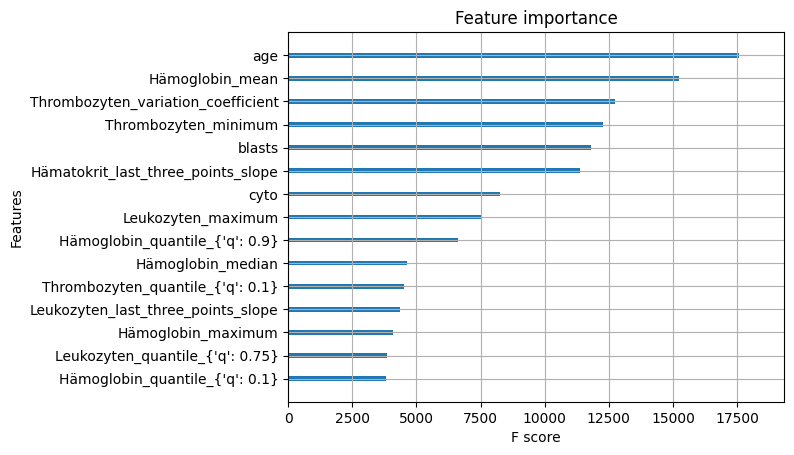

In [30]:
xgb.plot_importance(model, importance_type='gain', max_num_features=15, show_values=False)
#plt.title("Feature importance (Gain)")
plt.savefig("feature_importance.svg")

In [36]:
importance_dict = model.get_booster().get_score(importance_type='gain')
importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'gain': list(importance_dict.values())
})

# Sort by gain descending and get top 20 features
top_features = importance_df.sort_values(by='gain', ascending=False)['feature'].head(15).tolist()
top_features

['Thrombozyten_variation_coefficient',
 'Hämoglobin_mean',
 'Hämatokrit_last_three_points_slope',
 'Thrombozyten_minimum',
 'Hämoglobin_median',
 "Thrombozyten_quantile_{'q': 0.25}",
 "Hämoglobin_quantile_{'q': 0.9}",
 "Hämatokrit_quantile_{'q': 0.9}",
 "Hämoglobin_quantile_{'q': 0.5}",
 "Hämoglobin_quantile_{'q': 0.75}",
 'Leukozyten_variance',
 'Leukozyten_maximum',
 'Leukozyten_standard_deviation',
 'Hämoglobin_last_three_points_slope',
 "Hämoglobin_quantile_{'q': 0.25}"]

In [38]:
dataset = dataset[model.feature_names_in_]

In [39]:
dataset.shape

(6145, 213)

In [40]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(dataset)

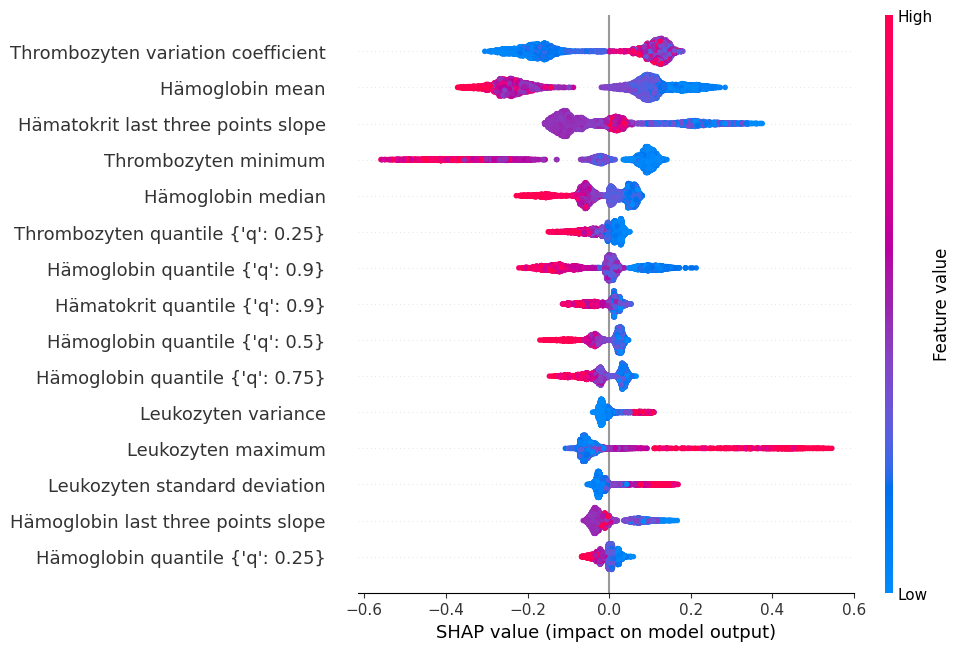

In [41]:
# get integer indices for your top_features list
feature_idx = [list(dataset.columns).index(f) for f in top_features]
feature_names = list(dataset.columns)
feature_names = [f.replace("_", " ") for f in feature_names]
feature_names[feature_names.index("blasts")] = "Bone-Marrow Blasts (%)"
feature_names[feature_names.index("cyto")] = "IPSS Karyotype classification"

# Create Explanation on full dataset
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=dataset,
    feature_names=feature_names
)

# Beeswarm plot of the top-20 most impactful features (auto-ranked)
shap.plots.beeswarm(explanation, max_display=20, show=False, group_remaining_features=False, order=feature_idx)
plt.savefig('shap_summary_plot_top_20_feat_imp.svg', format='svg', bbox_inches='tight')

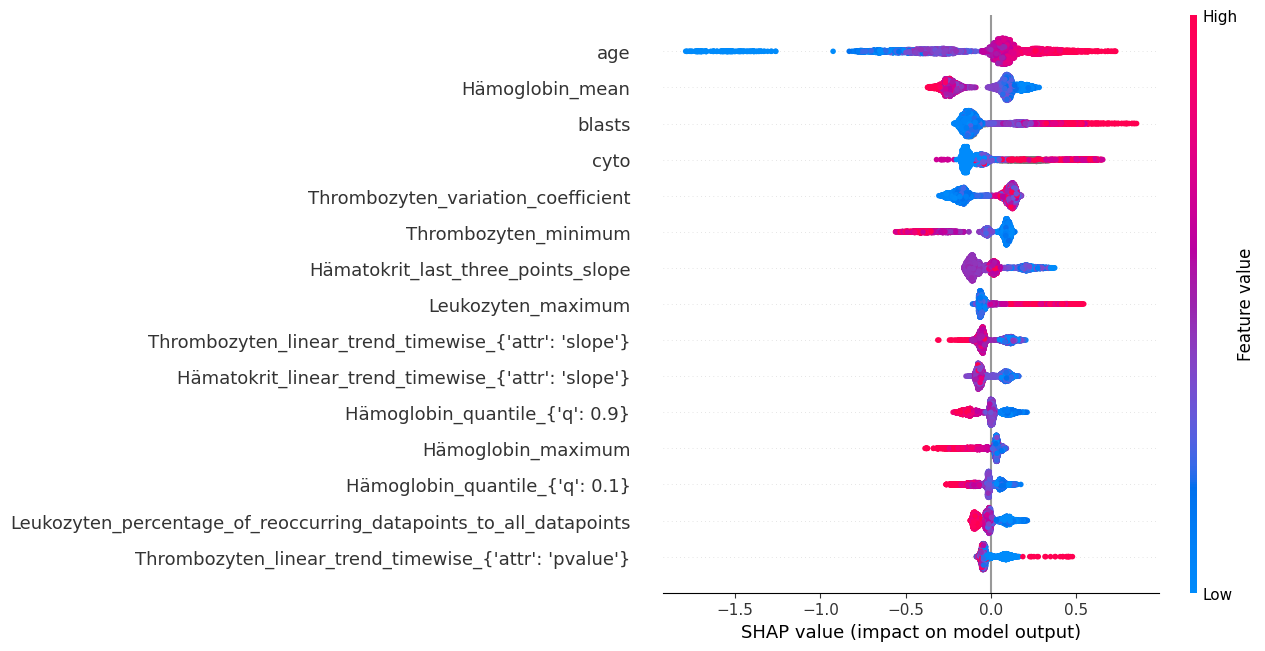

In [43]:
# 1. Create a SHAP Explanation object
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,  # base_values are needed but can be zeros here
    data=dataset,
    feature_names=dataset.columns
)

# 3. Plot
shap.plots.beeswarm(explanation, max_display=15, show=False, group_remaining_features=False)

# 4. Save
plt.savefig('shap_summary_plot_top_20_shap.svg', format='svg', bbox_inches='tight')



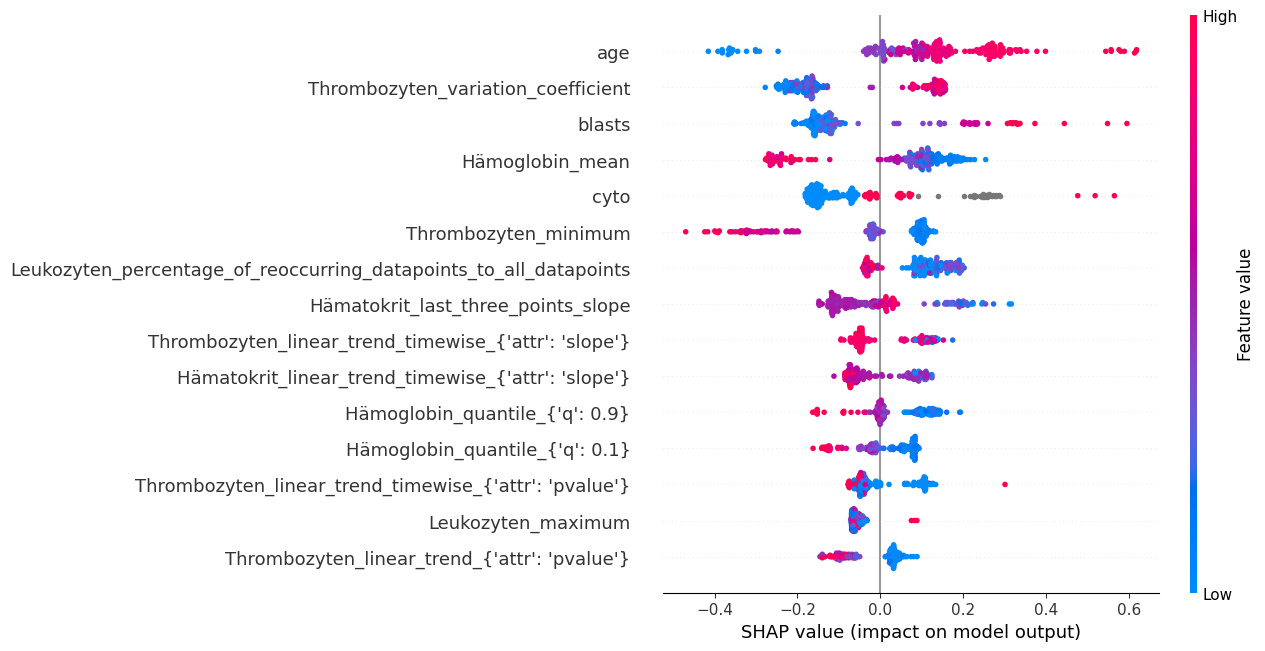

In [49]:
explainer_val = shap.TreeExplainer(model)
shap_values_val = explainer.shap_values(val_dataset)

val_dataset = val_dataset[model.feature_names_in_]
# 1. Create a SHAP Explanation object
explanation_val = shap.Explanation(
    values=shap_values_val,
    base_values=explainer_val.expected_value,  # base_values are needed but can be zeros here
    data=val_dataset,
    feature_names=val_dataset.columns
)

# 3. Plot
shap.plots.beeswarm(explanation_val, max_display=15, show=False, group_remaining_features=False)

# 4. Save
plt.savefig('shap_summary_plot_top_20_shap_val.svg', format='svg', bbox_inches='tight')

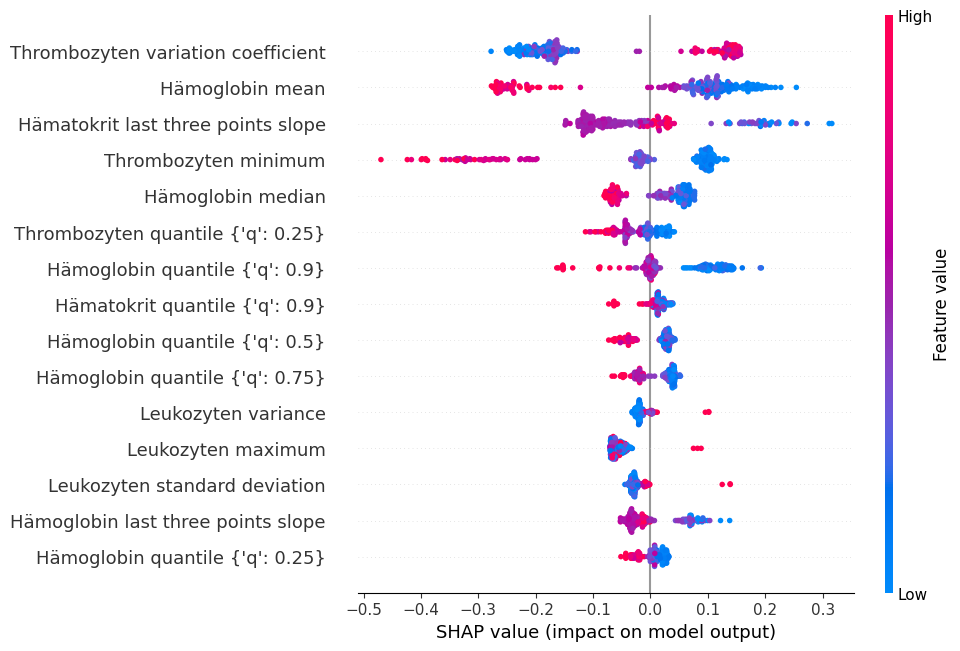

In [48]:
# get integer indices for your top_features list
feature_idx = [list(val_dataset.columns).index(f) for f in top_features]
feature_names = list(val_dataset.columns)
feature_names = [f.replace("_", " ") for f in feature_names]
feature_names[feature_names.index("blasts")] = "Bone-Marrow Blasts (%)"
feature_names[feature_names.index("cyto")] = "IPSS Karyotype classification"

explainer_val = shap.TreeExplainer(model)
shap_values_val = explainer.shap_values(val_dataset)

val_dataset = val_dataset[model.feature_names_in_]
# 1. Create a SHAP Explanation object
explanation_val = shap.Explanation(
    values=shap_values_val,
    base_values=explainer_val.expected_value,  # base_values are needed but can be zeros here
    data=val_dataset,
    feature_names=feature_names
)

# 3. Plot
shap.plots.beeswarm(explanation_val, max_display=15, show=False, group_remaining_features=False, order=feature_idx)

# 4. Save
plt.savefig('shap_summary_plot_top_20_feat_imp_val.svg', format='svg', bbox_inches='tight')

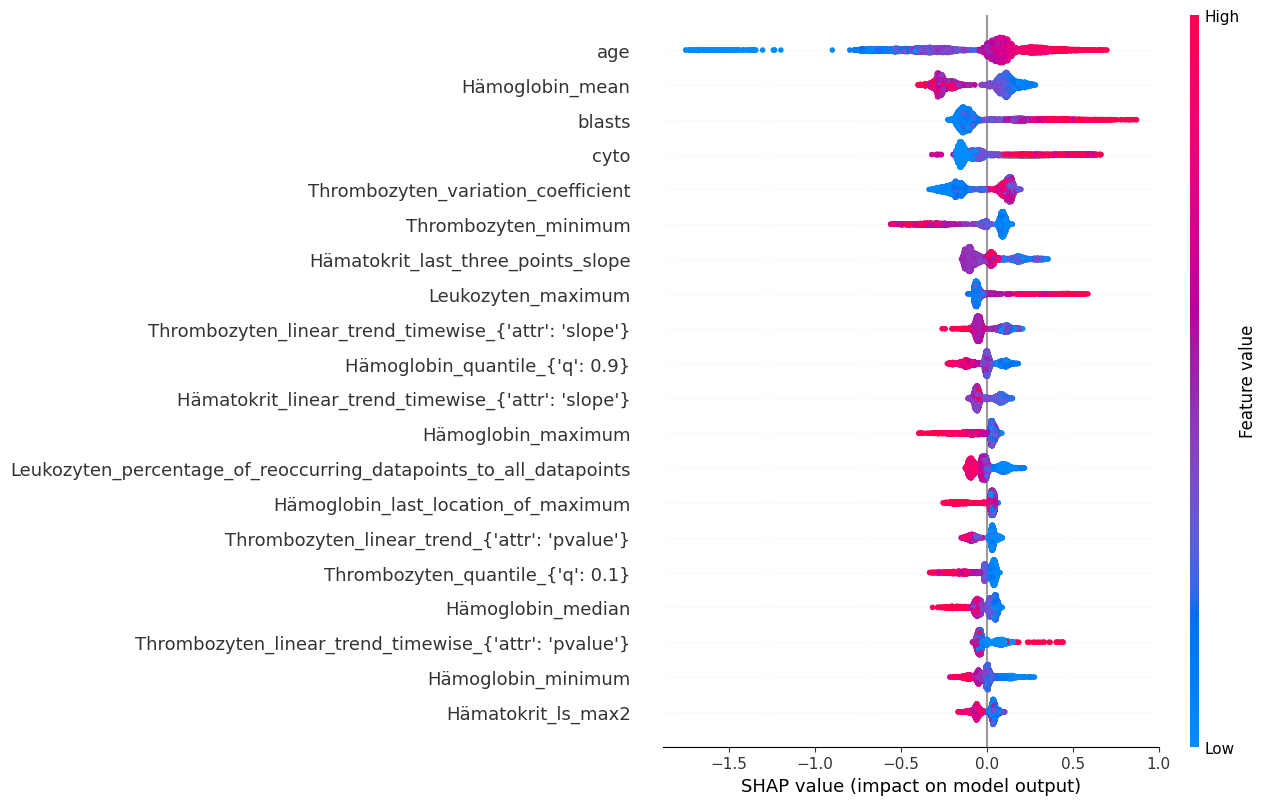

In [9]:
import numpy as np

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    'feature': dataset.columns,
    'mean_abs_shap': mean_abs_shap
})

top_shap_features = shap_importance.sort_values(by='mean_abs_shap', ascending=False)['feature'].head(20).tolist()

X_top_shap = dataset[top_shap_features]
shap_values_top_shap = shap_values[:, [dataset.columns.get_loc(c) for c in top_shap_features]]

# 2. Create a SHAP Explanation object
explanation = shap.Explanation(
    values=shap_values_top_shap,
    base_values=np.zeros(shap_values_top_shap.shape[0]),  # base_values are needed but can be zeros here
    data=X_top_shap,
    feature_names=top_shap_features
)

shap.plots.beeswarm(explanation, max_display=20, show=False)
plt.savefig('shap_summary_plot_top_20_shap.svg', format='svg', bbox_inches='tight')

In [4]:
# stability over time plots

quarter = list(range(1,33))
auroc_baseline = []
auprc_baseline = []
mse_baseline = []
auroc_model = []
auprc_model = []
mse_model = []
ratio = []

values = """Length: 1 quarters
Ratio: 0.32748538011695905
GBM metrics: 0.7953416149068323, 0.6110009179835969, 0.18159647909081908
GBM_baseline metrics: 0.8206521739130435, 0.6303175126785281, 0.21606289756615502
Length: 2 quarters
Ratio: 0.2911392405063291
GBM metrics: 0.8181288819875776, 0.6877374911786842, 0.16506449886586033
GBM_baseline metrics: 0.7547554347826086, 0.5782913763220836, 0.22234245653573886
Length: 3 quarters
Ratio: 0.2826086956521739
GBM metrics: 0.8461538461538461, 0.7174259126227428, 0.1643107957787306
GBM_baseline metrics: 0.7428127428127428, 0.5305745797090318, 0.2297320361895179
Length: 4 quarters
Ratio: 0.21238938053097345
GBM metrics: 0.8661048689138576, 0.7135265294381341, 0.14809972712802585
GBM_baseline metrics: 0.6706460674157304, 0.35449776029677504, 0.22987750649103456
Length: 5 quarters
Ratio: 0.25
GBM metrics: 0.8402366863905325, 0.7128290328655732, 0.15108160882180097
GBM_baseline metrics: 0.6651873767258384, 0.4147984766057317, 0.22560791086307888
Length: 6 quarters
Ratio: 0.23076923076923078
GBM metrics: 0.9006802721088436, 0.7856006283434713, 0.11381598929825582
GBM_baseline metrics: 0.6595238095238094, 0.41282838360004004, 0.21547421715117623
Length: 7 quarters
Ratio: 0.24675324675324675
GBM metrics: 0.882032667876588, 0.82096595816108, 0.11114301107762037
GBM_baseline metrics: 0.6778584392014518, 0.5098034822087351, 0.21301515702401846
Length: 8 quarters
Ratio: 0.20833333333333334
GBM metrics: 0.8339181286549707, 0.7752519914814996, 0.11850822246880169
GBM_baseline metrics: 0.6023391812865497, 0.353650550024498, 0.22847101331954514
Length: 9 quarters
Ratio: 0.14925373134328357
GBM metrics: 0.8754385964912281, 0.7001045296167246, 0.10042779905841444
GBM_baseline metrics: 0.7394736842105263, 0.33867373578700577, 0.2032074878308732
Length: 10 quarters
Ratio: 0.18867924528301888
GBM metrics: 0.788372093023256, 0.6214285714285713, 0.137064372400078
GBM_baseline metrics: 0.7651162790697674, 0.37178434592227694, 0.21777426873241468
Length: 11 quarters
Ratio: 0.1509433962264151
GBM metrics: 0.625, 0.374732905982906, 0.1592020629360493
GBM_baseline metrics: 0.7597222222222222, 0.3344935254803676, 0.2118059300350097
Length: 12 quarters
Ratio: 0.13043478260869565
GBM metrics: 0.7666666666666666, 0.6027777777777777, 0.15263919329483389
GBM_baseline metrics: 0.8041666666666667, 0.33245129870129875, 0.1872842582017156
Length: 13 quarters
Ratio: 0.16666666666666666
GBM metrics: 0.6122448979591837, 0.22089803312629402, 0.1929012367816933
GBM_baseline metrics: 0.6795918367346938, 0.3490150842945874, 0.18023493070770447
Length: 14 quarters
Ratio: 0.13333333333333333
GBM metrics: 0.673076923076923, 0.40555555555555556, 0.1673435454314845
GBM_baseline metrics: 0.7836538461538463, 0.35892857142857143, 0.16216477940300356
Length: 15 quarters
Ratio: 0.19444444444444445
GBM metrics: 0.6108374384236452, 0.39142857142857146, 0.19215648407055147
GBM_baseline metrics: 0.6798029556650246, 0.4501133786848072, 0.18693139684514243
Length: 16 quarters
Ratio: 0.14285714285714285
GBM metrics: 0.7708333333333334, 0.6237373737373737, 0.16441315150304056
GBM_baseline metrics: 0.6875, 0.2494047619047619, 0.17691207506556042
Length: 17 quarters
Ratio: 0.0625
GBM metrics: 0.8666666666666667, 0.6, 0.11482541479584853
GBM_baseline metrics: 0.9333333333333333, 0.6666666666666666, 0.14446572588684498
Length: 18 quarters
Ratio: 0.06896551724137931
GBM metrics: 0.5740740740740741, 0.54, 0.1698525798997528
GBM_baseline metrics: 0.8518518518518519, 0.26666666666666666, 0.16882888688377878
Length: 19 quarters
Ratio: nan
GBM metrics: nan, nan, nan
GBM_baseline metrics: nan, nan, nan
Length: 20 quarters
Ratio: 0.12
GBM metrics: 0.6515151515151515, 0.2383838383838384, 0.17196168739742554
GBM_baseline metrics: 0.7348484848484849, 0.2777777777777778, 0.15593534078611634
Length: 21 quarters
Ratio: 0.14814814814814814
GBM metrics: 0.6521739130434783, 0.2638888888888889, 0.18760428913514243
GBM_baseline metrics: 0.625, 0.22574786324786325, 0.17254461381216005
Length: 22 quarters
Ratio: 0.2
GBM metrics: 0.8099999999999999, 0.6502506265664161, 0.13025038168393313
GBM_baseline metrics: 0.565, 0.23929971988795518, 0.17812430600136725
Length: 23 quarters
Ratio: 0.25
GBM metrics: 0.8148148148148149, 0.6825396825396826, 0.14685811114826056
GBM_baseline metrics: 0.662037037037037, 0.3543650793650793, 0.20108595957880723
Length: 24 quarters
Ratio: 0.12
GBM metrics: 0.7121212121212122, 0.4714285714285714, 0.13498314236907885
GBM_baseline metrics: 0.5757575757575758, 0.17498514557338088, 0.149966788068145
Length: 25 quarters
Ratio: 0.15789473684210525
GBM metrics: 0.875, 0.7777777777777777, 0.10328264310030381
GBM_baseline metrics: 0.5, 0.1987012987012987, 0.15769640730892553
Length: 26 quarters
Ratio: 0.11764705882352941
GBM metrics: 0.7666666666666666, 0.375, 0.13198240613701132
GBM_baseline metrics: 0.39999999999999997, 0.14285714285714285, 0.1515700563822503
Length: 27 quarters
Ratio: 0.13636363636363635
GBM metrics: 0.6491228070175439, 0.47549019607843135, 0.1341034770205218
GBM_baseline metrics: 0.631578947368421, 0.22222222222222224, 0.14201660842380703
Length: 28 quarters
Ratio: 0.2
GBM metrics: 0.6388888888888888, 0.5166666666666666, 0.17687016727971078
GBM_baseline metrics: 0.7222222222222223, 0.3595238095238095, 0.1573988745196065
Length: 29 quarters
Ratio: 0.17647058823529413
GBM metrics: 0.7380952380952381, 0.3472222222222222, 0.13264778608182523
GBM_baseline metrics: 0.738095238095238, 0.3416666666666667, 0.14010774647060867
Length: 30 quarters
Ratio: 0.2
GBM metrics: 0.8333333333333334, 0.6333333333333333, 0.11952346942195681
GBM_baseline metrics: 0.7500000000000001, 0.3873015873015873, 0.14673456422144907
Length: 31 quarters
Ratio: 0.16666666666666666
GBM metrics: 1.0, 1.0, 0.08477025694314509
GBM_baseline metrics: 0.7, 0.3333333333333333, 0.13846116751306464
Length: 32 quarters
Ratio: 0.07692307692307693
GBM metrics: 1.0, 1.0, 0.07465849053709187
GBM_baseline metrics: 0.5833333333333333, 0.16666666666666666, 0.09986956689607508

"""

for value in values.split("\n"):
    if value.startswith("GBM metrics:"):
        trimmed_values = value[13:].split(", ")
        auroc_model.append(float(trimmed_values[0]))
        auprc_model.append(float(trimmed_values[1]))
        mse_model.append(float(trimmed_values[2]))
    elif value.startswith("GBM_baseline metrics:"):
        trimmed_values = value[22:].split(", ")
        auroc_baseline.append(float(trimmed_values[0]))
        auprc_baseline.append(float(trimmed_values[1]))
        mse_baseline.append(float(trimmed_values[2]))
    elif value.startswith("Ratio:"):
        ratio.append(float(value[7:]))

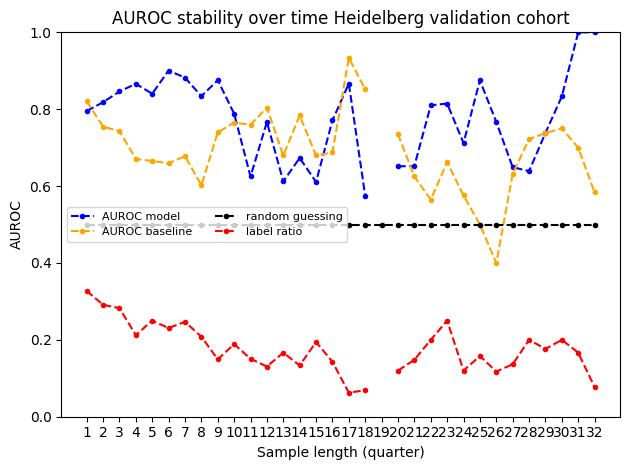

In [5]:
plt.clf()
plt.plot(auroc_model, label="AUROC model", color="blue", marker=".", linestyle="dashed")
plt.plot(auroc_baseline, label="AUROC baseline", color="orange", marker=".", linestyle="dashed")
plt.plot([0.5]*len(quarter), label="random guessing", color="black", marker=".", linestyle="dashed")
plt.plot(ratio, label="label ratio", color="red", marker=".", linestyle="dashed")
plt.xticks(labels=quarter, ticks=list(range(0,32)))
plt.ylim(0,1)
plt.legend(loc="center left", ncol=2, fontsize=8)
plt.title("AUROC stability over time Heidelberg validation cohort")
plt.ylabel("AUROC")
plt.xlabel("Sample length (quarter)")
plt.tight_layout()
plt.savefig("AUROC_over_time.svg")

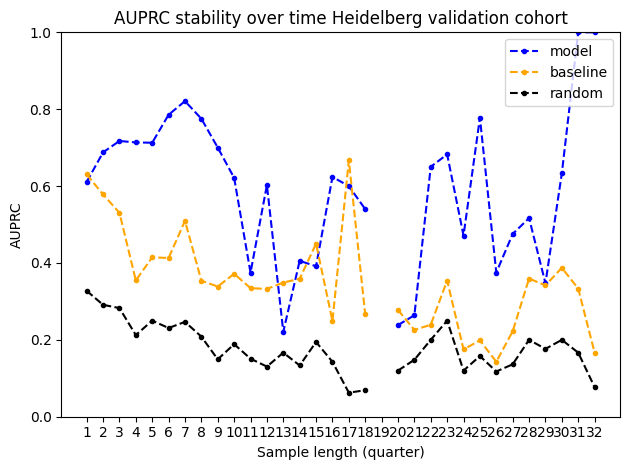

In [6]:
plt.clf()
plt.plot(auprc_model, label="model", color="blue", marker=".", linestyle="dashed")
plt.plot(auprc_baseline, label="baseline", color="orange", marker=".", linestyle="dashed")
plt.plot(ratio, label="random", color="black", marker=".", linestyle="dashed")
plt.xticks(labels=quarter, ticks=list(range(0,32)))
plt.ylim(0,1)
plt.legend(loc="upper right")
plt.title("AUPRC stability over time Heidelberg validation cohort")
plt.ylabel("AUPRC")
plt.xlabel("Sample length (quarter)")
plt.tight_layout()
plt.savefig("AUPRC_over_time.svg")

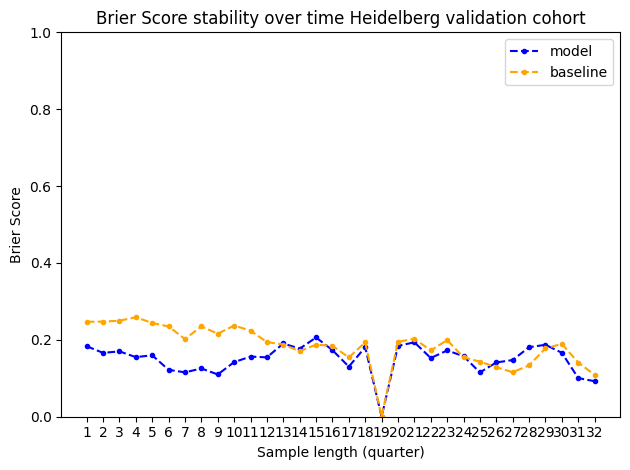

In [35]:
plt.clf()
plt.plot(mse_model, label="model", color="blue", marker=".", linestyle="dashed")
plt.plot(mse_baseline, label="baseline", color="orange", marker=".", linestyle="dashed")
plt.xticks(labels=quarter, ticks=list(range(0,32)))
plt.ylim(0,1)
plt.legend(loc="upper right")
plt.title("Brier Score stability over time Heidelberg validation cohort")
plt.ylabel("Brier Score")
plt.xlabel("Sample length (quarter)")
plt.tight_layout()
plt.savefig("Brier_over_time.svg")

<Figure size 640x480 with 0 Axes>

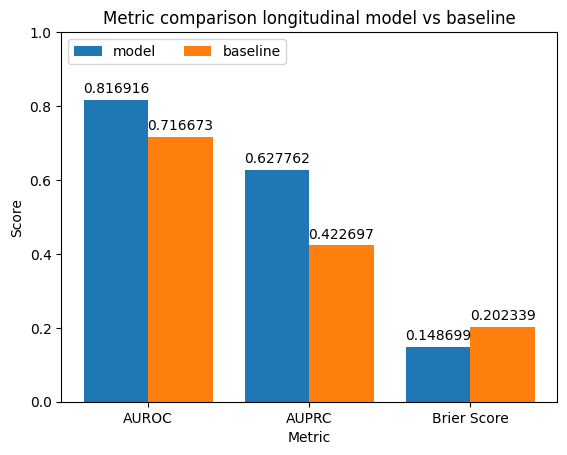

In [3]:
plt.clf()
labels = ["AUROC", "AUPRC", "Brier Score"]
x = np.arange(len(labels))
width = 0.4
fig, ax = plt.subplots()
multiplier = 0
rects = ax.bar(x+(width * multiplier), [0.8169158614454426, 0.6277623280380814, 0.14869940300707496], width, label="model")
ax.bar_label(rects,padding=3)
multiplier += 1
rects = ax.bar(x+(width * multiplier), [0.7166728824094479, 0.42269692936052883, 0.20233876754105293], width, label="baseline")
ax.bar_label(rects,padding=3)
multiplier += 1

ax.set_ylabel('Score')
ax.set_xlabel('Metric')
ax.set_title('Metric comparison longitudinal model vs baseline')
ax.set_xticks(x + (width/2), labels)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1)
plt.savefig("Metrics_heidelberg.svg")

<Figure size 640x480 with 0 Axes>

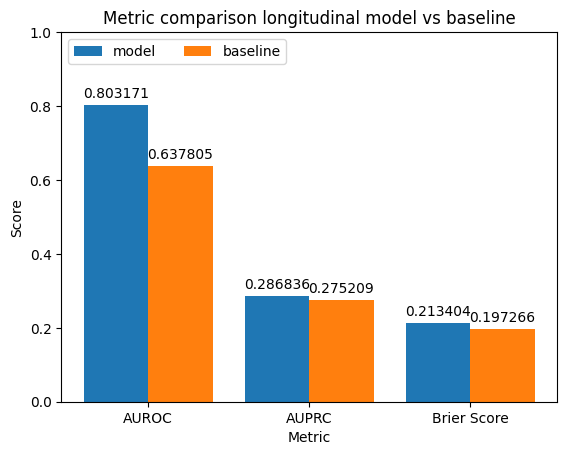

In [11]:
plt.clf()
labels = ["AUROC", "AUPRC", "Brier Score"]
x = np.arange(len(labels))
width = 0.4
fig, ax = plt.subplots()
multiplier = 0
rects = ax.bar(x+(width * multiplier), [0.8031707317073171, 0.286835951971822, 0.21340353753611244], width, label="model")
ax.bar_label(rects,padding=3)
multiplier += 1
rects = ax.bar(x+(width * multiplier), [0.6378048780487805, 0.2752086790238396, 0.1972662034191883], width, label="baseline")
ax.bar_label(rects,padding=3)
multiplier += 1

ax.set_ylabel('Score')
ax.set_xlabel('Metric')
ax.set_title('Metric comparison longitudinal model vs baseline')
ax.set_xticks(x + (width/2), labels)
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 1)
plt.savefig("Metrics_mannheim.svg")